# ALS Gut Microbiome Analysis Pipeline

**BIOL 3601, Spring 2026 - Project 6**
**Omar Moustafa (900222400)**

This is the analysis notebook for my project. The data are from Hertzberg et al. 2021 (NCBI BioProject PRJNA566436): nine ALS patients and their nine spouses. The background, methods, results, and discussion are in the report.


## Setup

The first cell installs the two non-default packages that the analysis needs. The second cell imports everything and sets a couple of plotting defaults.

In [1]:
!pip install -q scikit-bio statsmodels


In [2]:
# Imports.
import warnings
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from skbio.diversity import alpha_diversity, beta_diversity
from skbio.stats.distance import permanova
from skbio.stats.ordination import pcoa
from statsmodels.stats.multitest import multipletests

# Hide non-essential warnings to keep the output readable.
warnings.filterwarnings("ignore")

# Plotting defaults.
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Red for ALS, dark blue for Control. Same colors used throughout the report.
PALETTE = {"ALS": "#c0392b", "Control": "#2c3e50"}

# Fix the random seed so PERMANOVA gives the same p-value every run.
np.random.seed(42)


## Load the data

The analysis needs three tables: the sample metadata, the ASV count table, and the taxonomy. The next cell downloads them from the project repository if they are not already on disk.

In [3]:
# Look for a local data folder first; if not present, download from GitHub.
if Path("data/metadata.tsv").exists():
    DATA_DIR = Path("data")
elif Path("../data/metadata.tsv").exists():
    DATA_DIR = Path("../data")
else:
    DATA_DIR = Path("data")
    DATA_DIR.mkdir(exist_ok=True)
    BASE_URL = "https://raw.githubusercontent.com/ahmedmoustafa/als-gut-check/main/data"
    for name in ("metadata.tsv", "asv_table.tsv", "taxonomy.tsv"):
        print(f"Downloading {name}")
        urlretrieve(f"{BASE_URL}/{name}", DATA_DIR / name)

print(f"Using data from: {DATA_DIR.resolve()}")


Using data from: /Users/ahmed/Projects/als-gut-check/data


In [4]:
# Read in the three input tables.
metadata = pd.read_csv(DATA_DIR / "metadata.tsv", sep="\t")
asv = pd.read_csv(DATA_DIR / "asv_table.tsv", sep="\t", index_col=0)
tax = pd.read_csv(DATA_DIR / "taxonomy.tsv", sep="\t", index_col=0)

# Reorder the metadata rows to match the ASV table column order.
metadata = metadata.set_index("sample")
metadata = metadata.loc[asv.columns]
metadata.index.name = "sample"
metadata = metadata.reset_index()

print(f"{asv.shape[0]} ASVs across {asv.shape[1]} samples")
print(metadata["status"].value_counts().to_string())


275 ASVs across 18 samples
status
Control    9
ALS        9


## Filter rare ASVs and normalize

I keep only the ASVs that appear in at least 5 percent of samples, with a floor of two samples for this small cohort, and then convert the raw counts into per-sample relative abundances.

In [5]:
# Prevalence filter: drop any ASV present in fewer than 5% of samples
# (with a hard floor of 2 samples for a small cohort).
min_samples = max(2, int(np.ceil(0.05 * asv.shape[1])))
prevalence = (asv > 0).sum(axis=1)
asv_qc = asv.loc[prevalence >= min_samples]

# Relative abundance: each sample column sums to 1.
rel = asv_qc.div(asv_qc.sum(axis=0), axis=1)

sparsity = (asv_qc == 0).mean().mean()
print(f"ASVs before filter: {asv.shape[0]}")
print(f"ASVs after filter:  {asv_qc.shape[0]}")
print(f"Sparsity after filter: {sparsity:.0%}")


ASVs before filter: 275
ASVs after filter:  121
Sparsity after filter: 75%


## Community composition by phylum

Before looking at diversity statistics, it helps to see what the communities are actually made of. The next plot shows the relative abundance of each bacterial phylum in each sample. Samples are grouped by status (Control on the left, ALS on the right).

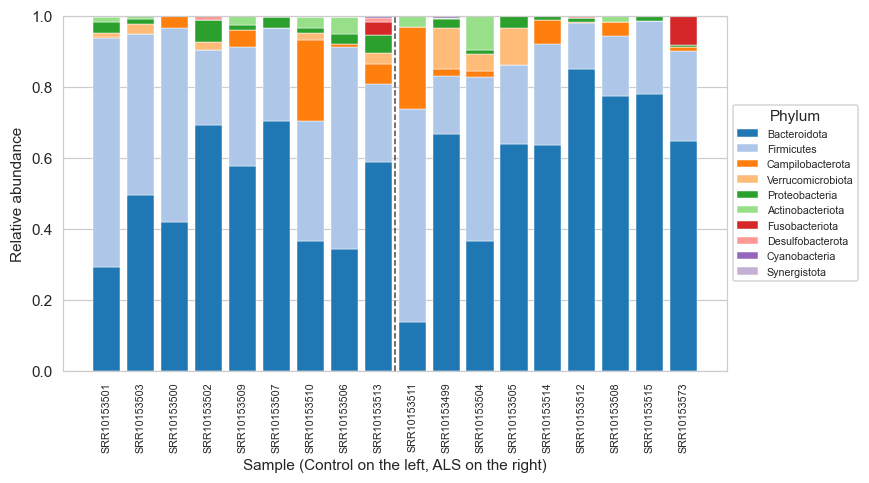

In [6]:
# Aggregate ASV-level relative abundances up to the phylum level.
phylum_labels = tax.loc[rel.index, "Phylum"].fillna("Unassigned")
rel_with_phylum = rel.copy()
rel_with_phylum["phylum"] = phylum_labels
phylum_rel = rel_with_phylum.groupby("phylum").sum()

# Order samples by status (then by pair) and order phyla by overall abundance.
sample_order = metadata.sort_values(["status", "pair"])["sample"].tolist()
phylum_rel = phylum_rel[sample_order]
phylum_rel = phylum_rel.loc[phylum_rel.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = sns.color_palette("tab20", n_colors=phylum_rel.shape[0])
bottom = np.zeros(phylum_rel.shape[1])
for i, (phylum, row) in enumerate(phylum_rel.iterrows()):
    ax.bar(
        range(phylum_rel.shape[1]), row.values,
        bottom=bottom, color=colors[i], label=phylum,
        edgecolor="white", linewidth=0.3,
    )
    bottom += row.values

# Mark the boundary between the Control and ALS halves.
n_control = (metadata["status"] == "Control").sum()
ax.axvline(n_control - 0.5, color="black", linewidth=1.0, linestyle="--", alpha=0.7)

ax.set_xticks(range(len(sample_order)))
ax.set_xticklabels(sample_order, rotation=90, fontsize=7)
ax.set_ylabel("Relative abundance")
ax.set_xlabel("Sample (Control on the left, ALS on the right)")
ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7, title="Phylum")
plt.tight_layout()
plt.show()


## Alpha diversity (Shannon)

The Shannon index is computed for each sample. The two groups are compared first with a boxplot, then with a paired dot plot that draws a line for each household pair, and finally with the formal paired Wilcoxon signed-rank test.

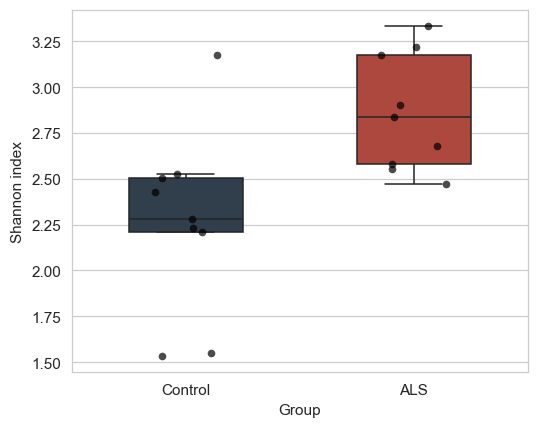

In [7]:
# Compute the Shannon index for each sample.
# scikit-bio expects samples as rows, so transpose the count table first.
shannon = alpha_diversity("shannon", asv_qc.T.values, ids=asv_qc.columns)

alpha_df = shannon.to_frame("shannon")
alpha_df = alpha_df.merge(metadata.set_index("sample"), left_index=True, right_index=True)
alpha_df = alpha_df.reset_index()

# Boxplot of Shannon index per group, with each sample shown as a dot.
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(
    data=alpha_df, x="status", y="shannon",
    order=["Control", "ALS"], palette=PALETTE, ax=ax,
    width=0.5, showfliers=False,
)
sns.stripplot(
    data=alpha_df, x="status", y="shannon",
    order=["Control", "ALS"], color="black", alpha=0.7, jitter=0.15, ax=ax,
)
ax.set_xlabel("Group")
ax.set_ylabel("Shannon index")
plt.tight_layout()
plt.show()


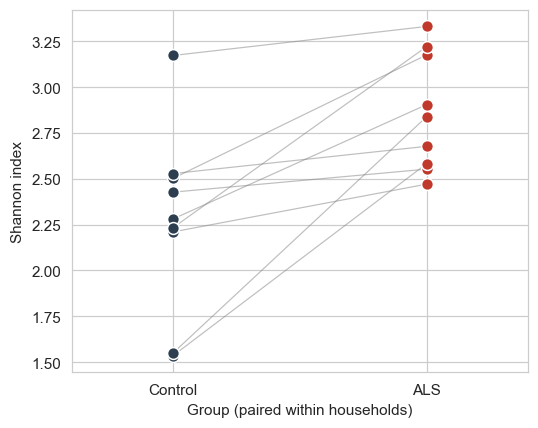

In [8]:
# Paired dot plot: one line per household pair, connecting the Control
# sample on the left to the ALS sample on the right.
fig, ax = plt.subplots(figsize=(5, 4))
for pair_id, pair_data in alpha_df.groupby("pair"):
    pair_pivot = pair_data.set_index("status")["shannon"]
    if "Control" not in pair_pivot.index or "ALS" not in pair_pivot.index:
        continue
    y_control = pair_pivot["Control"]
    y_als = pair_pivot["ALS"]
    # Light grey line connecting the two points of the pair.
    ax.plot([0, 1], [y_control, y_als], color="grey", linewidth=0.8, alpha=0.5)
    ax.scatter(0, y_control, color=PALETTE["Control"], s=60, zorder=3, edgecolor="white")
    ax.scatter(1, y_als, color=PALETTE["ALS"], s=60, zorder=3, edgecolor="white")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Control", "ALS"])
ax.set_xlim(-0.4, 1.4)
ax.set_ylabel("Shannon index")
ax.set_xlabel("Group (paired within households)")
plt.tight_layout()
plt.show()


In [9]:
# Paired Wilcoxon signed-rank test within household pairs.
# Each row of the pivoted table is one pair: ALS column and Control column.
paired = alpha_df.pivot(index="pair", columns="status", values="shannon").dropna()
stat, pvalue = stats.wilcoxon(paired["ALS"], paired["Control"])
mean_pair_diff = (paired["ALS"] - paired["Control"]).mean()

print(f"Number of pairs: {len(paired)}")
print(f"Mean Shannon difference (ALS - Control): {mean_pair_diff:+.3f}")
print(f"Paired Wilcoxon statistic: {stat:.3f}")
print(f"Paired Wilcoxon p-value:   {pvalue:.4f}")


Number of pairs: 9
Mean Shannon difference (ALS - Control): +0.590
Paired Wilcoxon statistic: 0.000
Paired Wilcoxon p-value:   0.0039


## Beta diversity (Bray-Curtis), PCoA, and PERMANOVA

Beta diversity is computed with the Bray-Curtis dissimilarity. The distance matrix is visualized with Principal Coordinates Analysis (PCoA), and group separation is tested with PERMANOVA.

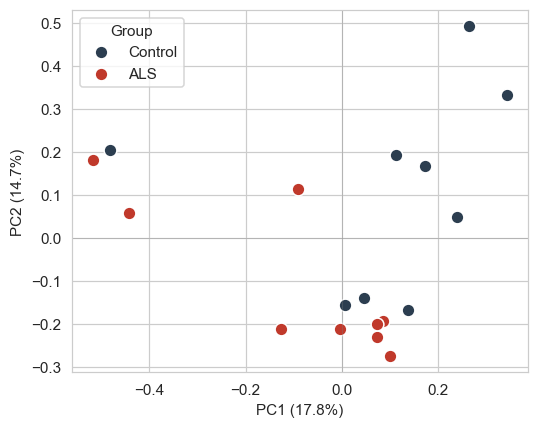

In [10]:
# Pairwise Bray-Curtis distances between all samples (samples as rows).
bc = beta_diversity("braycurtis", rel.T.values, ids=rel.columns)

# Project the distance matrix into two dimensions for plotting.
ord_result = pcoa(bc)
coords = ord_result.samples[["PC1", "PC2"]].copy()
coords = coords.join(metadata.set_index("sample"))
var_explained = ord_result.proportion_explained

fig, ax = plt.subplots(figsize=(5, 4))
for grp in ("Control", "ALS"):
    sub = coords[coords["status"] == grp]
    ax.scatter(
        sub["PC1"], sub["PC2"],
        s=70, color=PALETTE[grp], label=grp,
        edgecolor="white", linewidth=1.0,
    )
ax.set_xlabel(f"PC1 ({var_explained['PC1']:.1%})")
ax.set_ylabel(f"PC2 ({var_explained['PC2']:.1%})")
ax.legend(title="Group")
ax.axhline(0, color="grey", linewidth=0.5, alpha=0.4)
ax.axvline(0, color="grey", linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()


In [11]:
# PERMANOVA test: is the average within-group distance smaller than the
# average between-group distance?
grouping = metadata.set_index("sample").loc[list(bc.ids), "status"]
result = permanova(bc, grouping, permutations=999)
print(result)


method name               PERMANOVA
test statistic name        pseudo-F
sample size                      18
number of groups                  2
test statistic             1.705897
p-value                       0.016
number of permutations          999
Name: PERMANOVA results, dtype: object


## Driver genera (per-genus Mann-Whitney with Benjamini-Hochberg correction)

ASV-level relative abundances are aggregated to the genus level. Each genus is then tested with a two-sided Mann-Whitney U test, and the resulting p-values are FDR-corrected. The results are shown in two ways: a volcano plot of the whole genus landscape, and a bar chart of the top ten hits.

In [12]:
# Aggregate ASV-level relative abundances up to the genus level.
# Drop any ASV that does not have a genus assignment in the taxonomy table.
genus_labels = tax.loc[rel.index, "Genus"].dropna()
rel_with_genus = rel.loc[genus_labels.index].copy()
rel_with_genus["genus"] = genus_labels
genus_rel = rel_with_genus.groupby("genus").sum()

print(f"Number of genera after aggregation: {genus_rel.shape[0]}")

# Lists of sample IDs for each group.
als_samples = metadata.loc[metadata["status"] == "ALS", "sample"].tolist()
ctrl_samples = metadata.loc[metadata["status"] == "Control", "sample"].tolist()

# Run a two-sided Mann-Whitney U test for each genus.
records = []
for genus, row in genus_rel.iterrows():
    als_values = row[als_samples].values
    ctrl_values = row[ctrl_samples].values
    # Skip the genus if both groups are all zeros.
    if als_values.sum() == 0 and ctrl_values.sum() == 0:
        continue
    u_stat, p_value = stats.mannwhitneyu(
        als_values, ctrl_values, alternative="two-sided"
    )
    # Tiny epsilon avoids log(0) when one of the means is zero.
    log2_fc = np.log2((als_values.mean() + 1e-6) / (ctrl_values.mean() + 1e-6))
    records.append({
        "genus": genus,
        "mean_ALS": als_values.mean(),
        "mean_Control": ctrl_values.mean(),
        "log2_fold_change": log2_fc,
        "p_value": p_value,
    })

diff_df = pd.DataFrame(records)
diff_df["q_value"] = multipletests(diff_df["p_value"], method="fdr_bh")[1]
diff_df = diff_df.sort_values("q_value").reset_index(drop=True)

# Show the top 10 genera by adjusted p-value.
print(diff_df.head(10).round(4).to_string(index=False))


Number of genera after aggregation: 51


                       genus  mean_ALS  mean_Control  log2_fold_change  p_value  q_value
             Parabacteroides    0.0197        0.0004            5.5963   0.0013   0.0683
[Ruminococcus] torques group    0.0060        0.0003            4.2374   0.0036   0.0927
             Subdoligranulum    0.0077        0.0017            2.2001   0.0085   0.1410
                     Blautia    0.0218        0.0053            2.0529   0.0111   0.1410
           Lachnoclostridium    0.0076        0.0000           12.8874   0.0140   0.1423
              Parasutterella    0.0221        0.0044            2.3360   0.0290   0.2063
                     UCG-002    0.0174        0.0040            2.1367   0.0364   0.2063
        Escherichia-Shigella    0.0013        0.0082           -2.6624   0.0349   0.2063
                Ruminococcus    0.0093        0.0014            2.7175   0.0266   0.2063
                 Bacteroides    0.2563        0.0987            1.3771   0.0423   0.2155


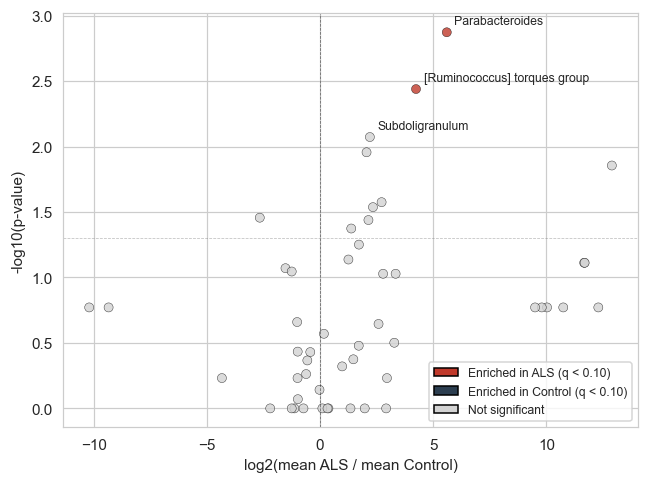

In [13]:
# Volcano plot: log2 fold change on the x-axis, -log10(p-value) on the y-axis.
# Points colored by direction of change when the FDR q-value is below 0.10.
neg_log_p = -np.log10(diff_df["p_value"])
significant_mask = diff_df["q_value"] < 0.10

point_colors = []
for is_sig, lfc in zip(significant_mask, diff_df["log2_fold_change"]):
    if is_sig and lfc > 0:
        point_colors.append(PALETTE["ALS"])
    elif is_sig and lfc < 0:
        point_colors.append(PALETTE["Control"])
    else:
        point_colors.append("lightgrey")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(
    diff_df["log2_fold_change"], neg_log_p,
    c=point_colors, s=35, alpha=0.8, edgecolor="black", linewidth=0.3,
)

# Reference lines: zero fold change and the nominal p = 0.05 threshold.
ax.axvline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.5)
ax.axhline(-np.log10(0.05), color="grey", linewidth=0.5, linestyle="--", alpha=0.5)

# Label the top three genera by adjusted p-value.
for _, row in diff_df.head(3).iterrows():
    ax.annotate(
        row["genus"],
        (row["log2_fold_change"], -np.log10(row["p_value"])),
        xytext=(5, 5), textcoords="offset points", fontsize=8,
    )

ax.set_xlabel("log2(mean ALS / mean Control)")
ax.set_ylabel("-log10(p-value)")
ax.legend(handles=[
    Patch(facecolor=PALETTE["ALS"], edgecolor="black", label="Enriched in ALS (q < 0.10)"),
    Patch(facecolor=PALETTE["Control"], edgecolor="black", label="Enriched in Control (q < 0.10)"),
    Patch(facecolor="lightgrey", edgecolor="black", label="Not significant"),
], loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


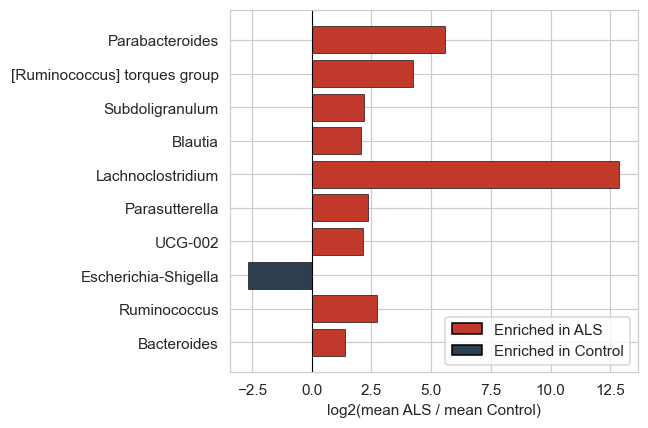

In [14]:
# Bar chart of the top 10 genera, colored by direction of change.
# Bars to the right of zero: enriched in ALS. Bars to the left: enriched in Control.
top10 = diff_df.head(10).iloc[::-1]  # reverse so the top genus is at the top of the chart
bar_colors = [PALETTE["ALS"] if x > 0 else PALETTE["Control"] for x in top10["log2_fold_change"]]

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(top10["genus"], top10["log2_fold_change"], color=bar_colors, edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("log2(mean ALS / mean Control)")

legend_handles = [
    Patch(facecolor=PALETTE["ALS"], edgecolor="black", label="Enriched in ALS"),
    Patch(facecolor=PALETTE["Control"], edgecolor="black", label="Enriched in Control"),
]
ax.legend(handles=legend_handles, loc="lower right")
plt.tight_layout()
plt.show()
